In [ ]:
# Standard modules
import pandas as pd
import numpy as np

# Preprocessing modules
from sklearn.preprocessing import StandardScaler, OrdinalEncoder

# Pipeline module
from sklearn.pipeline import Pipeline

# Imputation modules
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

# Performance metric modules
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Plotting modules
import matplotlib.pyplot as plt
import matplotlib.cm as cm
plt.style.use('dark_background')
%matplotlib inline

In [ ]:
np.set_printoptions(precision=2)

In [ ]:
import tensorflow as tf

In [ ]:
dfICU = pd.read_csv('ICU_filtered.csv')

print('ICU dataset')
print('-----------')
print('Initial number of samples = %d'%(dfICU.shape[0]))
print('Initial number of features = %d\n'%(dfICU.shape[1]))
dfICU.head(5)

ICU dataset
-----------
Initial number of samples = 7886
Initial number of features = 36



,recordid,Length_of_stay,In-hospital_death,Age,Gender,Height,CCU,CSRU,SICU,DiasABP_first,...,Na_first,PaCO2_first,PaO2_first,Platelets_first,SysABP_first,WBC_first,Weight,pH_first,MechVent,UrineOutputSum
0,132539,5,0,54,0.0,NaN,0,0,1,NaN,...,137.0,NaN,NaN,221.0,NaN,11.2,NaN,NaN,0,NaN
1,132540,8,0,76,1.0,175.3,0,1,0,67.0,...,139.0,34.0,344.0,164.0,105.0,7.4,80.6,7.45,1,5.0
2,132541,19,0,44,0.0,NaN,0,0,0,81.0,...,137.0,37.0,65.0,72.0,148.0,4.2,56.7,7.51,1,14.0
3,132543,9,0,68,1.0,180.3,0,0,0,NaN,...,140.0,NaN,NaN,391.0,NaN,11.5,84.6,NaN,0,NaN
4,132545,4,0,88,0.0,NaN,0,0,0,NaN,...,140.0,NaN,NaN,109.0,NaN,3.8,NaN,NaN,0,NaN


In [ ]:
dfICU.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7886 entries, 0 to 7885
Data columns (total 36 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   recordid           7886 non-null   int64  
 1   Length_of_stay     7886 non-null   int64  
 2   In-hospital_death  7886 non-null   int64  
 3   Age                7886 non-null   int64  
 4   Gender             7878 non-null   float64
 5   Height             4139 non-null   float64
 6   CCU                7886 non-null   int64  
 7   CSRU               7886 non-null   int64  
 8   SICU               7886 non-null   int64  
 9   DiasABP_first      5509 non-null   float64
 10  GCS_first          7768 non-null   float64
 11  Glucose_first      7786 non-null   float64
 12  HR_first           7768 non-null   float64
 13  MAP_first          5532 non-null   float64
 14  NIDiasABP_first    6905 non-null   float64
 15  NIMAP_first        6902 non-null   float64
 16  NISysABP_first     6910 

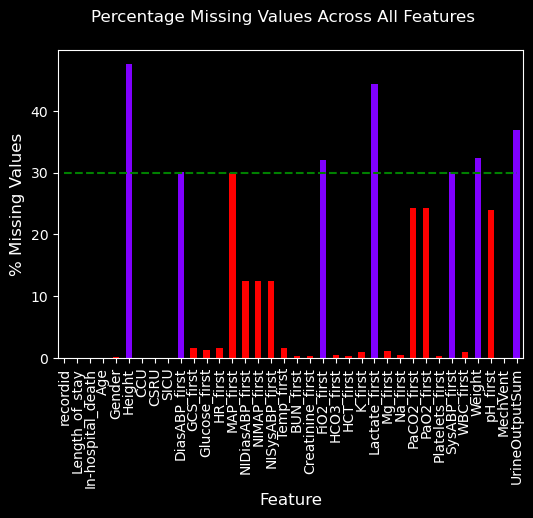

In [ ]:
cutoff = 30
fig = plt.figure(figsize=(6, 4))
percent_missing = (dfICU.isna().sum() / dfICU.shape[0]) * 100
percent_missing.plot(kind = 'bar', color = cm.rainbow(np.linspace(0, 1, 2))[(percent_missing <= cutoff).values.astype(int)])
plt.plot(np.arange(dfICU.shape[1]), np.repeat(cutoff, dfICU.shape[1]), 'g--')
fig.suptitle('Percentage Missing Values Across All Features', fontsize = 12)
plt.xlabel('Feature', fontsize = 12)
plt.ylabel('% Missing Values', fontsize = 12);

In [ ]:
dfICU = dfICU.loc[:, dfICU.columns[percent_missing <= cutoff]]

dfICU.loc[dfICU['CCU'] == 1, 'ICU'] = 1
dfICU.loc[dfICU['CSRU'] == 1, 'ICU'] = 2
dfICU.loc[dfICU['SICU'] == 1, 'ICU'] = 3
dfICU.loc[(dfICU['CCU'] == 0 ) & (dfICU['CSRU'] == 0) & (dfICU['SICU'] == 0), 'ICU'] = 4
dfICU.drop(['CCU', 'CSRU', 'SICU'], axis = 1, inplace = True)

In [ ]:
ordinal_features = ['GCS_first']
categorical_features = [ 'Gender', 'ICU', 'MechVent']
continuous_features = dfICU.columns[~dfICU.columns.isin(ordinal_features + categorical_features)].to_list()
dfICU.head(5)

,recordid,Length_of_stay,In-hospital_death,Age,Gender,GCS_first,Glucose_first,HR_first,MAP_first,NIDiasABP_first,...,K_first,Mg_first,Na_first,PaCO2_first,PaO2_first,Platelets_first,WBC_first,pH_first,MechVent,ICU
0,132539,5,0,54,0.0,15.0,205.0,73.0,NaN,65.0,...,4.4,1.5,137.0,NaN,NaN,221.0,11.2,NaN,0,3.0
1,132540,8,0,76,1.0,3.0,105.0,88.0,79.0,38.0,...,4.3,3.1,139.0,34.0,344.0,164.0,7.4,7.45,1,2.0
2,132541,19,0,44,0.0,7.0,141.0,100.0,107.0,84.0,...,3.3,1.9,137.0,37.0,65.0,72.0,4.2,7.51,1,4.0
3,132543,9,0,68,1.0,15.0,129.0,79.0,NaN,63.0,...,4.0,2.1,140.0,NaN,NaN,391.0,11.5,NaN,0,4.0
4,132545,4,0,88,0.0,15.0,113.0,93.0,NaN,41.0,...,6.0,1.5,140.0,NaN,NaN,109.0,3.8,NaN,0,4.0


In [ ]:
X_train = dfICU.drop(np.where(dfICU.iloc[:, 2]==1)[0])
Y_train = dfICU['In-hospital_death'].drop(np.where(dfICU.iloc[:, 2]==1)[0])
X_test = dfICU
Y_test = dfICU['In-hospital_death']

In [ ]:
ordinal_transformer = Pipeline(steps = [('ordinalenc', OrdinalEncoder()), ('imputer', SimpleImputer(missing_values = np.NaN, strategy = 'constant'))])

categorical_transformer = Pipeline(steps = [('imputer', SimpleImputer(missing_values = np.NaN, strategy = 'median'))])

continuous_transformer = Pipeline(steps = [('scaler', StandardScaler()), ('imputer', SimpleImputer(missing_values = np.NaN, strategy = 'mean'))])

preprocessor = ColumnTransformer(transformers = [('ord', ordinal_transformer, ordinal_features),
                                                 ('cat', categorical_transformer, categorical_features),
                                                 ('num', continuous_transformer, continuous_features)
                                                 ])

model_pipeline = Pipeline(steps = [('preprocessor', preprocessor)])

In [ ]:
X_train_transformed =  model_pipeline.fit_transform(X_train, Y_train)
X_test_transformed = model_pipeline.transform(X_test)

In [ ]:
batch_size = 256
max_epochs = 100
learning_rate = 1e-3
latent_dim = 12
hidden_dim = 20
original_dim = X_train_transformed.shape[1]

In [ ]:
training_dataset = tf.data.Dataset.from_tensor_slices(X_train_transformed).batch(batch_size)

In [ ]:
class Encoder(tf.keras.layers.Layer):
  def __init__(self, hidden_dim, latent_dim):
    super(Encoder, self).__init__()
    self.encoder_layer1 = tf.keras.layers.Dense(units = hidden_dim, activation = tf.nn.relu)
    self.encoder_layer2 = tf.keras.layers.Dense(units = latent_dim, activation = tf.nn.relu)

  def call(self,input_features):
    a = self.encoder_layer1(input_features)
    a = self.encoder_layer2(a)
    return a

In [ ]:
class Decoder(tf.keras.layers.Layer):
  def __init__(self,latent_dim, hidden_dim, original_dim):
    super(Decoder, self).__init__()
    self.decoder_layer1 = tf.keras.layers.Dense(units = hidden_dim, activation = tf.nn.relu)
    self.decoder_layer2 = tf.keras.layers.Dense(units = original_dim, activation = tf.nn.relu)

  def call(self,encoded_feature):
    a = self.decoder_layer1(encoded_feature)
    a = self.decoder_layer2(a)
    return a

In [ ]:
class Autoencoder(tf.keras.Model):
  def __init__(self,latent_dim,hidden_dim,original_dim):
    super(Autoencoder, self). __init__()
    self.loss=[]
    self.encoder = Encoder(hidden_dim = hidden_dim, latent_dim = latent_dim)
    self.decoder = Decoder(latent_dim = latent_dim, hidden_dim = hidden_dim, original_dim = original_dim)

  def call(self,input_features):
    encoded_features = self.encoder(input_features)
    reconstructed_features = self.decoder(encoded_features)
    return reconstructed_features

In [ ]:
autoencoder = Autoencoder(latent_dim = latent_dim, hidden_dim = hidden_dim, original_dim = original_dim)

In [ ]:
opt = tf.keras.optimizers.Adam(learning_rate = learning_rate)

In [ ]:
def loss(true, pred):
  return tf.reduce_mean(tf.square(tf.subtract(true, pred)))

In [ ]:
@tf.function
def train(loss, model, opt, original_features):
  with tf.GradientTape() as g:
    pred_features = tf.cast(model(original_features), tf.float64)
    reconstruction_error = loss(original_features, pred_features)
  gradients = g.gradient(reconstruction_error, model.trainable_variables)
  gradient_variables = zip(gradients, model.trainable_variables)
  opt.apply_gradients(gradient_variables)

  return reconstruction_error

In [ ]:
loss_train_epoch = tf.keras.metrics.Mean()
loss_train_epoch_plot = np.empty(max_epochs)

for epoch in range(max_epochs):
  epoch_loss = 0
  for step, batch_features in enumerate(training_dataset):
    loss_batch = train(loss, autoencoder, opt, batch_features)
    loss_train_epoch(loss_batch)
  loss_train_epoch_plot[epoch] = loss_train_epoch.result().numpy()
  print(f'Epoch {epoch+1}, loss = {loss_train_epoch_plot[epoch]}')

Epoch 1, loss = 3.325411081314087
Epoch 2, loss = 2.8259060382843018
Epoch 3, loss = 2.2922732830047607
Epoch 4, loss = 1.9485949277877808
Epoch 5, loss = 1.7288663387298584
Epoch 6, loss = 1.5745787620544434
Epoch 7, loss = 1.4582864046096802
Epoch 8, loss = 1.3668031692504883
Epoch 9, loss = 1.2926753759384155
Epoch 10, loss = 1.2312458753585815
Epoch 11, loss = 1.17954683303833
Epoch 12, loss = 1.1354161500930786
Epoch 13, loss = 1.097299337387085
Epoch 14, loss = 1.0639350414276123
Epoch 15, loss = 1.0344038009643555
Epoch 16, loss = 1.0079747438430786
Epoch 17, loss = 0.9840223789215088
Epoch 18, loss = 0.9621451497077942
Epoch 19, loss = 0.9420603513717651
Epoch 20, loss = 0.9235049486160278
Epoch 21, loss = 0.9062983393669128
Epoch 22, loss = 0.8902885913848877
Epoch 23, loss = 0.8753442168235779
Epoch 24, loss = 0.8613709807395935
Epoch 25, loss = 0.8482763767242432
Epoch 26, loss = 0.8359729051589966
Epoch 27, loss = 0.8243926167488098
Epoch 28, loss = 0.8134884834289551
Epoch

Text(0.5, 1.0, 'Loss vs. Epoch')

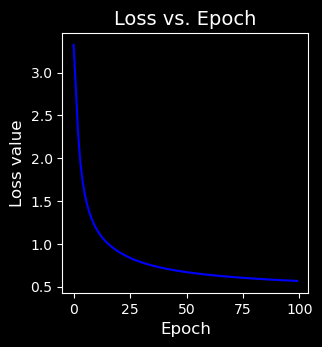

In [ ]:
# Plot train loss as a function of epoch:
fig, ax = plt.subplots(1, 1, figsize = (4, 4))
fig.tight_layout(pad = 4.0)
ax.plot(loss_train_epoch_plot, 'b')
ax.set_xlabel('Epoch', fontsize = 12)
ax.set_ylabel('Loss value', fontsize = 12)
ax.set_title('Loss vs. Epoch', fontsize = 14)

247/247 [==============================] - 0s 2ms/step


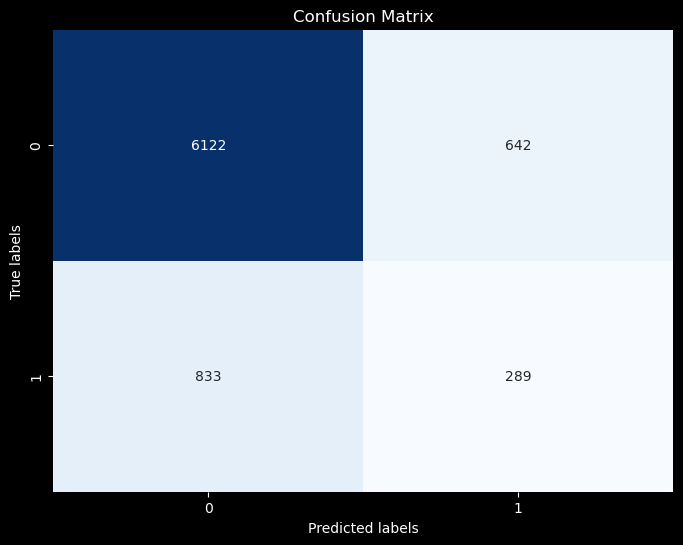

In [ ]:
import seaborn as sns

reconstructions = autoencoder.predict(X_test_transformed)
mse = np.mean(np.square(X_test_transformed - reconstructions), axis=1)

threshold = 0.8

y_pred = np.where(mse > threshold, 1, 0)

def plot_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.xlabel('Predicted labels')
    plt.ylabel('True labels')
    plt.title('Confusion Matrix')
    plt.show()

plot_confusion_matrix(Y_test.values, y_pred)



In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score


accuracy = accuracy_score(Y_test.values, y_pred)
precision = precision_score(Y_test.values, y_pred)
recall = recall_score(Y_test.values, y_pred)

# Print the results
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)


Accuracy: 0.8129596753740806
Precision: 0.3104189044038668
Recall: 0.25757575757575757


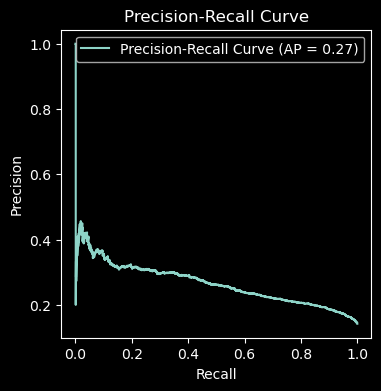

In [ ]:
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score

# Calculate precision-recall curve
precision, recall, _ = precision_recall_curve(Y_test.values, mse)

# Calculate average precision score
average_precision = average_precision_score(Y_test.values, mse)

# Plot the precision-recall curve
plt.figure(figsize=(4, 4))
plt.plot(recall, precision, label=f'Precision-Recall Curve (AP = {average_precision:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()
